In [1]:
import sys

In [2]:
print(sys.executable)

/home/simonque/Documents/code/env/bin/python3


In [3]:
print(sys.prefix)

/home/simonque/Documents/code/env


Regularized Least Squares Error
===================================

# Import Libraries

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import argparse
import csv

In [5]:
# parser = argparse.ArgumentParser(
#     description = "Perform regularized linear model regression from scratch.")
# parser.add_argument("filepath", type=str, help="Path to the input file")
# parser.add_argument("lambda_val", type=float, help="Lambda value used for LSE and Steepest Descent")
# parser.add_argument("num_polynomial_bases", type=int, help="Number of polynomial bases")
# args = parser.parse_args()

# Define input filename and parameters

In [6]:
filename = "input.txt"
lambda_val = 0
num_polynomial_bases = 8

# Read the input file and store input data points into a list 

In [7]:
datapoints = []
with open(filename, 'r', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    for row in csv_reader:
        datapoints.append([float(i) for i in row])
num_datapoints = len(datapoints)
print(f"number of datapoints: {num_datapoints}\n")

datapoints_arr = np.zeros((num_datapoints, 2), dtype=np.float32)

i = 0
for datapoint in datapoints:
    datapoints_arr[i,0] = datapoint[0]
    datapoints_arr[i,1] = datapoint[1]
    i+=1;

print(datapoints_arr)

number of datapoints: 23

[[-5.         51.764053  ]
 [-4.7959185  45.423065  ]
 [-4.591837   41.27445   ]
 [-3.9795918  26.636217  ]
 [-3.5714285  20.256805  ]
 [-2.9591837  11.618429  ]
 [-2.7551022  10.450525  ]
 [-1.7346939   1.8480983 ]
 [-1.3265306  -1.040535  ]
 [-0.9183673  -4.6146307 ]
 [-0.71428573 -1.3871977 ]
 [-0.30612245 -1.9916444 ]
 [ 0.10204082 -0.9129246 ]
 [ 0.71428573  6.63482   ]
 [ 1.1224489   9.546867  ]
 [ 1.7346939  15.720161  ]
 [ 1.9387755  20.622517  ]
 [ 2.5510204  33.4806    ]
 [ 2.9591837  40.76392   ]
 [ 3.9795918  66.89976   ]
 [ 4.387755   78.44316   ]
 [ 4.591837   86.99157   ]
 [ 5.         99.78726   ]]


# DIY matrix functions

## Matrix Transpose

In [8]:
def diy_transpose(input_matrix: np.array):
    if len(input_matrix.shape) == 1:
        input_matrix = np.expand_dims(input_matrix, -1)
    transposed_shape = input_matrix.shape[::-1]
    transposed_matrix = np.zeros(shape=transposed_shape, dtype=input_matrix.dtype)
    for i in range(transposed_shape[0]):
        for j in range(transposed_shape[1]):
            transposed_matrix[i,j] = input_matrix[j,i]
    return np.squeeze(transposed_matrix)

## Matrix multiplication

In [9]:
def diy_dot(A: np.array, B: np.array):
    if len(A.shape) == 1:
        A = np.expand_dims(A, 0)
    if len(B.shape) == 1:
        B = np.expand_dims(B, -1)
    # print(A.shape, B.shape)
    
    if (A.shape[1] != B.shape[0]):
        raise ValueError("A and B shapes do not fit for multiplication!")
    else:
        
        
        m = A.shape[0]
        t = A.shape[1]
        n = B.shape[1]
        
        C = np.zeros(shape=(m,n), dtype=A.dtype)
        # for each row in A
        for i in range(m):
            # for each column in B
            for j in range(n):
                for k in range(t):
                    C[i,j] += A[i,k] * B[k,j]
        return np.squeeze(C)
                

## Matrix abs

In [10]:
def diy_abs(A: np.array):
    A_abs = np.zeros(shape=A.shape, dtype=A.dtype)
    if len(A.shape) == 1:
        for i in range(A.shape[0]):
            if A[i] < 0:
                A_abs[i] = A[i] * -1
            else:
                A_abs[i] = A[i]
    else:
        for i in range(A.shape[0]):
            A[i] = diy_abs(A[i])
            
    return A_abs

## Matrix sum

In [11]:
def diy_sum(A:np.array):
    sum = 0
    if len(A.shape) == 1:
        for i in range(A.shape[0]):
            sum += A[i]
    else:
        for i in range(A.shape[0]):
            sum += diy_sum(A[i])
    return sum
    

## DIY argmax

In [12]:
def diy_argmax(A:np.array):
    argmax = 0
    if len(A.shape) == 1:
        maxval = A[0]
        for i in range(A.shape[0]):
            if A[i] > maxval:
               argmax = i 
    else:
        argmax = diy_argmax(A[i])
    return argmax

# Closed-Form Least Squares Error 

## Create the design matrix
The design matrix is an n x b matrix where n is the number of data points and b is the number of basis functions. Each row is a data point, and each column is a basis function applied to the data point.

$\theta$

In [13]:
'''
A is the design matrix composed of a ones column and basis function columns.
b is the y values 
'''
b = np.zeros((num_datapoints), dtype=np.float32)
b = datapoints_arr[:,1]
    
A = np.zeros((num_datapoints, num_polynomial_bases), dtype=np.float32)
for basis in range(num_polynomial_bases):
    A[:,basis] = datapoints_arr[:,0] ** basis


In [14]:
A

array([[ 1.00000000e+00, -5.00000000e+00,  2.50000000e+01,
        -1.25000000e+02,  6.25000000e+02, -3.12500000e+03,
         1.56250000e+04, -7.81250000e+04],
       [ 1.00000000e+00, -4.79591846e+00,  2.30008335e+01,
        -1.10310127e+02,  5.29038391e+02, -2.53722485e+03,
         1.21683232e+04, -5.83582891e+04],
       [ 1.00000000e+00, -4.59183693e+00,  2.10849667e+01,
        -9.68187256e+01,  4.44575806e+02, -2.04141956e+03,
         9.37386621e+03, -4.30432656e+04],
       [ 1.00000000e+00, -3.97959185e+00,  1.58371515e+01,
        -6.30253983e+01,  2.50815353e+02, -9.98142761e+02,
         3.97220068e+03, -1.58077383e+04],
       [ 1.00000000e+00, -3.57142854e+00,  1.27551022e+01,
        -4.55539360e+01,  1.62692627e+02, -5.81045044e+02,
         2.07516089e+03, -7.41128906e+03],
       [ 1.00000000e+00, -2.95918369e+00,  8.75676823e+00,
        -2.59128857e+01,  7.66809845e+01, -2.26913132e+02,
         6.71477661e+02, -1.98702563e+03],
       [ 1.00000000e+00, -2.755102

In [15]:
b

array([51.764053 , 45.423065 , 41.27445  , 26.636217 , 20.256805 ,
       11.618429 , 10.450525 ,  1.8480983, -1.040535 , -4.6146307,
       -1.3871977, -1.9916444, -0.9129246,  6.63482  ,  9.546867 ,
       15.720161 , 20.622517 , 33.4806   , 40.76392  , 66.89976  ,
       78.44316  , 86.99157  , 99.78726  ], dtype=float32)

## LU decomposition

In [16]:
'''
Doolittle Algorithm
Source: https://www.scicoding.com/how-to-calculate-lu-decomposition-in-python/
'''
def diy_lu_decomposition(input_matrix: np.array):
    input_shape = input_matrix.shape
    # create lower and upper matrices 
    L = np.zeros(shape=(input_shape), dtype=np.float32)
    U = np.zeros(shape=(input_shape), dtype=np.float32)
        
    # calculate the U matrix
    for i in range(input_shape[0]):
        for j in range(i, input_shape[0]):
            lu_sum = 0
            for k in range(i):
                lu_sum += L[i,k] * U[k,j]
            U[i,j] = input_matrix[i,j] - lu_sum

        for j in range(i, input_shape[0]):
            # initialize L diagonal to 1
            if (i == j):
                L[i,i] = 1
            else:
                lu_sum = 0
                for k in range(i):
                    lu_sum += L[j,k] * U[k,i]
                L[j,i] = (input_matrix[j,i] - lu_sum) / U[i,i]
            
    return L, U
# L, U = lu_decomposition(A)

# print("L: \n", L)
# print("U: \n", U)

In [17]:
# testing comparison with scipy LU decomposition
from scipy.linalg import lu
M = np.array([[10,12], [6, 8]])
L, U = lu(M, True)
print(f"L = ")
print(L)
print(f"U = ")
print(U)

L,U = diy_lu_decomposition(M)
print("DIY implementation")
print(f"L = ")
print(L)
print(f"U = ")
print(U)

L = 
[[1.  0. ]
 [0.6 1. ]]
U = 
[[10.  12. ]
 [ 0.   0.8]]
DIY implementation
L = 
[[1.  0. ]
 [0.6 1. ]]
U = 
[[10.        12.       ]
 [ 0.         0.7999997]]


## Normal LSE Equation with L2 Regularization

In [18]:
I = np.zeros(shape=(num_polynomial_bases,num_polynomial_bases), dtype=np.float32)
for i in range(num_polynomial_bases):
    I[i,i] = 1
I

array([[1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [19]:
A_t =  diy_transpose(A)
A_t

array([[ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00,  1.00000000e+00],
       [-5.00000000e+00, -4.79591846e+00, -4.59183693e+00,
        -3.97959185e+00, -3.57142854e+00, -2.95918369e+00,
        -2.75510216e+00, -1.73469388e+00, -1.32653058e+00,
        -9.18367326e-01, -7.14285731e-01, -3.06122452e-01,
         1.02040820e-01,  7.14285731e-01,  1.12244892e+00,
         1.73469388e+00,  1.93877554e+00,  2.55102038e+00,
         2.95918369e+00,  3.97959185e+00,  4.38775492e+00,
         4.59183693e+00,  5.00000000e+00],
       [ 2.50000000e+01,  2.30008335e+01,  2.10849667e+01,
         1.58371515e+01,  1.2

In [20]:
# x = (A^t A + lI)^-1 A^t b
# LU = A^t A + lI
L, U = diy_lu_decomposition(diy_dot(A_t, A) + lambda_val * I)
L,U

(array([[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [-1.55279577e-01,  1.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [ 9.79256916e+00, -1.56502038e-01,  1.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [-3.04936957e+00,  1.77312927e+01, -1.16590030e-01,
          1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [ 1.73680893e+02, -3.99659872e+00,  2.36797695e+01,
         -1.72930881e-01,  1.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [-6.60097046e+01,  3.61668396e+02, -4.08095455e+00,
          2.98612823e+01, -3.44466984e-01,  1.00000000e+00,
          0.00000000e+00,  0.00000000e+00],
        [ 3.5431

In [21]:
# x = (LU)^-1 A^t b
# LUx = A^t b = c

c = diy_dot(A_t, b)
c

array([6.5821533e+02, 8.9376343e+02, 1.1683053e+04, 1.4997564e+04,
       2.3810253e+05, 2.9352609e+05, 5.1469665e+06, 6.0829660e+06],
      dtype=float32)

## Forward Substitution

In [22]:
'''
Ax=b
solve for x
'''
def forward_sub(A: np.array, b: np.array):
    n = A.shape[0]
    x = np.zeros(shape=n, dtype=np.float32)
    for i in range(n):
        temp = 0
        for j in range(i):
            temp += A[i,j] * x[j]
        x[i] = (b[i] - temp) / A[i,i]
    return x

In [23]:
# Ux = z
# Lz = c
# Solve lower triangular system via forward substitution
# solve for intermediate matrix z


# forward substitution
z = forward_sub(L, c)

# z[0] = c[0] / L[0,0]
# z[1] = (c[1] - L[1,0] * z[0]) / L[1,1]
# z[2] = (c[2] - L[2,1] * z[1] - L[2,0] * z[0]) / L[2,2]
z

array([  658.21533 ,   995.9708  ,  5393.305   ,   -26.33789 ,
          46.828125,  -424.03125 ,  2998.5     , -3273.      ],
      dtype=float32)

## Backward substitution

In [24]:
'''
Ax=b
solve for x
'''
def backward_sub(A: np.array, b: np.array):
    n = A.shape[0]
    x = np.zeros(shape=n, dtype=np.float32)
    for i in range(n-1,-1,-1):
        temp = 0
        for j in range(n-1,i,-1):
            temp += A[i,j] * x[j]
        x[i] = (b[i] - temp) / A[i,i]
    return x

In [25]:
# Ux = z
# Solve upper triangular system via backward substitution
# solve for x
x = backward_sub(U,z)
# x[2] = z[2] / U[2,2]
# x[1] = (z[1] - U[1,2] * x[2]) / U[1,1]
# x[0] = (z[0] - U[0,2] * x[2] - U[0,1] * x[1]) / U[0,0]
x

array([-5.9103525e-01,  4.9530339e+00,  3.3603776e+00, -5.0753478e-02,
       -3.9484203e-02,  6.1338814e-03,  1.1050877e-03, -1.7397611e-04],
      dtype=float32)

## Calculate the total error

In [26]:
# regressed_y_vals = np.zeros(shape=(num_datapoints), dtype=np.float32)
# for d_idx in range(num_datapoints):
#     for basis in range(num_polynomial_bases):
#         regressed_y_vals[d_idx] += x[basis] * datapoints_arr[d_idx,0] ** basis
# regressed_y_vals

In [27]:
def compute_error(A, x, b):
    Ax = diy_dot(A, x)
    
    error = diy_sum(diy_abs(Ax - b) ** 2)
    return error

In [28]:
error = compute_error(A, x, b)
print(f"Total error: {error}")

Total error: 22.231914520263672


# Print equation of curve

In [29]:
equation = ""
if x[-1] < -1:
    equation += "-"
for i in range(num_polynomial_bases-1,-1,-1):
    equation += f"{abs(x[i]):.8f} "
    if i > 0:
        equation += f"x ^ {i} "
        if x[i-1] < 0:
            equation += "- "
        else:
            equation += "+ "
print(f"Curve of best fit: {equation}")
       

Curve of best fit: 0.00017398 x ^ 7 + 0.00110509 x ^ 6 + 0.00613388 x ^ 5 - 0.03948420 x ^ 4 - 0.05075348 x ^ 3 + 3.36037755 x ^ 2 + 4.95303392 x ^ 1 - 0.59103525 


# Visualization

In [30]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math

In [31]:
'''
Function to visualize the datapoints and the regressed trendline
'''
def plot_datapoints_trendline(datapoints_arr: np.array, 
                              num_bases: int,
                              lambda_val: float,
                              equation: str,
                                error: float,
                             filename: str):
    # get min and max x and y values of the sample data 
    min_x = np.min(datapoints_arr[:,0])
    max_x = np.max(datapoints_arr[:,0])
    min_y = np.min(datapoints_arr[:,1])
    max_y = np.max(datapoints_arr[:,1])
    x_bounds = (math.floor(min_x - 1), math.ceil(max_x + 1))
    y_bounds = (math.floor(min_y - 1), math.ceil(max_y + 1))

    fig,ax = plt.subplots(figsize = (10,6))
    # set limits
    ax.set_xlim(x_bounds[0], x_bounds[1])
    ax.set_ylim(y_bounds[0], y_bounds[1])
    # plot curve
    curve_x = np.linspace(min_x, max_x, 1000)
    curve_y = 0
    for i in range(num_bases):
        curve_y += x[i] * curve_x ** i
    ax.plot(curve_x, curve_y, label="trendline", color=((0.0,0.0, 1.0)))
    # plot points
    ax.scatter(datapoints_arr[:,0], datapoints_arr[:,1], label="datapoints", s=80, c=[[1.0,0.0, 0.0]], marker="X")
    ax.text(min_x - 0.5, max_y-15, f"equation = {equation}")
    ax.text(min_x - 0.5, max_y-20, f"no. datapoints = {datapoints_arr.shape[0]}")
    ax.text(min_x - 0.5, max_y-25, f"num_bases = {num_bases}")
    ax.text(min_x - 0.5, max_y-30, f"lambda = {lambda_val}")
    ax.text(min_x - 0.5, max_y-35, f"error = {error:.4f}")
    ax.legend(loc="upper left")
    plt.title(filename,fontsize=16, fontweight='bold')
    fig.savefig(filename)
    plt.show()

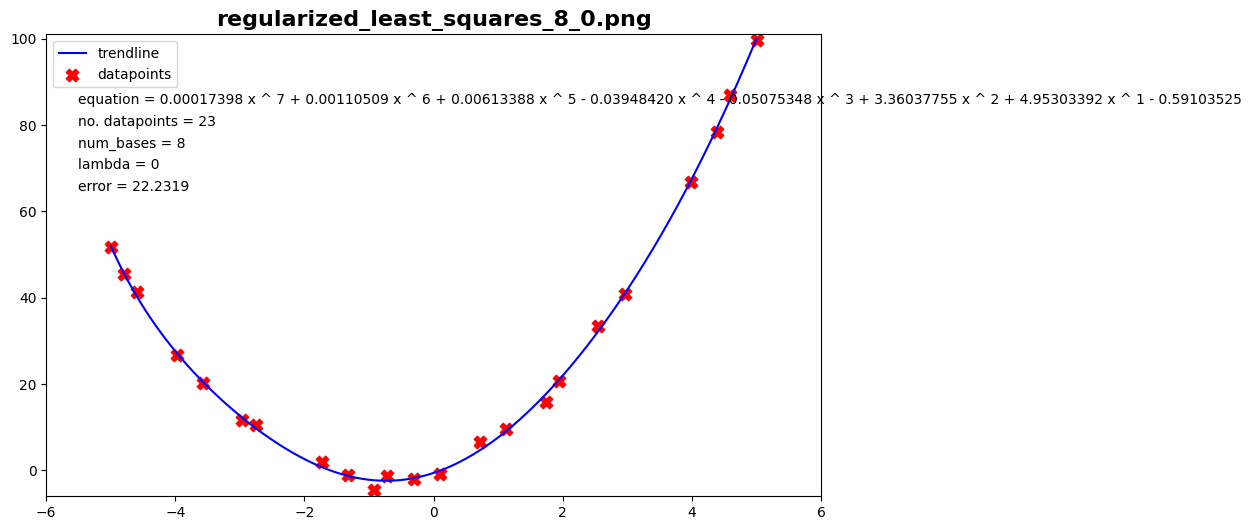

In [32]:
plot_datapoints_trendline(datapoints_arr, 
                          num_polynomial_bases, 
                          lambda_val,
                          equation,
                          error,
                          f"regularized_least_squares_{num_polynomial_bases}_{lambda_val}.png")